In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/maryclauds/sar-image-patches/epoch_90.pth.tar
/kaggle/input/datasets/maryclauds/sar-image-patches/SAR_Dataset/SAR_Dataset/train_LR/patch_005814.png
/kaggle/input/datasets/maryclauds/sar-image-patches/SAR_Dataset/SAR_Dataset/train_LR/patch_005553.png
/kaggle/input/datasets/maryclauds/sar-image-patches/SAR_Dataset/SAR_Dataset/train_LR/patch_004128.png
/kaggle/input/datasets/maryclauds/sar-image-patches/SAR_Dataset/SAR_Dataset/train_LR/patch_004006.png
/kaggle/input/datasets/maryclauds/sar-image-patches/SAR_Dataset/SAR_Dataset/train_LR/patch_001142.png
/kaggle/input/datasets/maryclauds/sar-image-patches/SAR_Dataset/SAR_Dataset/train_LR/patch_005910.png
/kaggle/input/datasets/maryclauds/sar-image-patches/SAR_Dataset/SAR_Dataset/train_LR/patch_002437.png
/kaggle/input/datasets/maryclauds/sar-image-patches/SAR_Dataset/SAR_Dataset/train_LR/patch_002769.png
/kaggle/input/datasets/maryclauds/sar-image-patches/SAR_Dataset/SAR_Dataset/train_LR/patch_005063.png
/kaggle/input

In [2]:
# Pull the original open-source SRGAN code
!git clone https://github.com/Lornatang/SRGAN-PyTorch.git /kaggle/working/SRGAN-PyTorch

# Move into the folder
%cd /kaggle/working/SRGAN-PyTorch

# Delete any line containing 'torch' from the text file
!sed -i '/torch/d' requirements.txt

# Install the rest of the libraries safely!
!pip install -r requirements.txt

Cloning into '/kaggle/working/SRGAN-PyTorch'...
remote: Enumerating objects: 3631, done.
remote: Counting objects: 100% (920/920), done.
remote: Compressing objects: 100% (283/283), done.
remote: Total 3631 (delta 690), reused 810 (delta 633), pack-reused 2711 (from 1)
Receiving objects: 100% (3631/3631), 2.98 MiB | 10.66 MiB/s, done.
Resolving deltas: 100% (2385/2385), done.
/kaggle/working/SRGAN-PyTorch
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for typing: filename=typing-3.7.4.3-py3-none-any.whl size=26304 sha256=4f6d1e527cd6837009898b6a4b235796c5611c057502cb0ae0103f99a451e577
  Stored in directory: /root/.cache/pip/wheels/12/98/52/2bffe242a9a487f00886e43b8ed8dac46456702e11a0d6abef
Successfully built typing


In [3]:
!find /kaggle/input -maxdepth 3

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/maryclauds
/kaggle/input/datasets/maryclauds/sar-image-patches


In [4]:
# Find the exact path to your 90-epoch brain
!find /kaggle/input -name "epoch_90.pth.tar"

# Find the exact path to your High-Res images
!find /kaggle/input -type d -name "train_HR"

/kaggle/input/datasets/maryclauds/sar-image-patches/epoch_90.pth.tar
/kaggle/input/datasets/maryclauds/sar-image-patches/SAR_Dataset/SAR_Dataset/train_HR


In [5]:
import yaml

# Open the original YAML file
with open('./configs/train/SRGAN_x4-ImageNet.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# 1. Fix the Hardware and Compiler
cfg['DEVICE_ID'] = 0
cfg['MODEL']['EMA']['COMPILED'] = False
cfg['MODEL']['G']['COMPILED'] = False
cfg['MODEL']['D']['COMPILED'] = False

# 2. Map your Image Folders
base_path = "/kaggle/input/datasets/maryclauds/sar-image-patches/SAR_Dataset/SAR_Dataset"
cfg['TRAIN']['DATASET']['TRAIN_GT_IMAGES_DIR'] = f"{base_path}/train_HR"
cfg['TEST']['DATASET']['PAIRED_TEST_GT_IMAGES_DIR'] = f"{base_path}/train_HR"
cfg['TEST']['DATASET']['PAIRED_TEST_LR_IMAGES_DIR'] = f"{base_path}/train_LR"

# 3. Link your 90-Epoch Brain
cfg['TRAIN']['CHECKPOINT']['PRETRAINED_G_MODEL'] = "/kaggle/input/datasets/maryclauds/sar-image-patches/epoch_90.pth.tar"

# 4. Set the Save Directory so you don't lose data
cfg['TEST']['SAVE_IMAGE_DIR'] = "/kaggle/working/samples/images/"

# Save the updated file back to the folder
with open('./configs/train/SRGAN_x4-ImageNet.yaml', 'w') as f:
    yaml.dump(cfg, f)

print("✅ Phase 2 Configuration successfully updated for Kaggle!")

✅ Phase 2 Configuration successfully updated for Kaggle!


In [6]:
!python train_gan.py --config_path ./configs/train/SRGAN_x4-ImageNet.yaml

2026-03-16 16:44:45.772194: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773679485.926961      79 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773679485.971542      79 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773679486.346096      79 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773679486.346161      79 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773679486.346170      79 computation_placer.cc:177] computation placer alr

In [7]:
!grep "EPOCHS:" ./configs/train/SRGAN_x4-ImageNet.yaml

    EPOCHS: 18


In [8]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# The exact folder we told the YAML file to save images in
output_folder = "/kaggle/working/samples/images/"

if os.path.exists(output_folder):
    # Grab all the generated PNGs and sort them
    files = sorted([f for f in os.listdir(output_folder) if f.endswith('.png')])
    
    if len(files) > 0:
        print(f"✅ Found {len(files)} generated test images! Displaying samples...")
        
        # Display up to 3 images side-by-side
        images_to_show = min(3, len(files))
        plt.figure(figsize=(18, 6))
        
        for i in range(images_to_show):
            img_path = os.path.join(output_folder, files[i])
            img = mpimg.imread(img_path)
            
            plt.subplot(1, images_to_show, i+1)
            plt.imshow(img, cmap='gray') # SAR images look best in grayscale
            plt.title(files[i], fontsize=10)
            plt.axis('off')
            
        plt.tight_layout()
        plt.show()
    else:
        print("Folder exists, but no PNG images were found inside.")
else:
    print(f"Could not find the folder: {output_folder}")

Folder exists, but no PNG images were found inside.


In [9]:
!find /kaggle/working -name "*.pth.tar"

/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/epoch_6.pth.tar
/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/epoch_15.pth.tar
/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/epoch_14.pth.tar
/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/epoch_16.pth.tar
/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/epoch_17.pth.tar
/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/epoch_8.pth.tar
/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/epoch_18.pth.tar
/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/epoch_13.pth.tar
/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/epoch_2.pth.tar
/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/epoch_3.pth.tar
/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/epoch_1.pth.tar
/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/epoch_4.pth.tar
/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/epoch_5.pth.tar
/kaggle/working/SRGAN-PyTorch/samples/SRGAN_x4-ImageNet/ep

**Test the images with the 18 epochs using g_best**

In [10]:
import os
import yaml
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Force the notebook into the correct folder!
os.chdir('/kaggle/working/SRGAN-PyTorch')

config_file = './configs/test/SRGAN_x4-ImageNet-Set5.yaml'

# 2. Auto-Edit the Test Configuration
with open(config_file, 'r') as f:
    cfg = yaml.safe_load(f)

# Using the EXACT keys from your cat command!
cfg['DEVICE_ID'] = 0
cfg['MODEL']['G']['COMPILED'] = False
cfg['MODEL_WEIGHTS_PATH'] = "/kaggle/working/SRGAN-PyTorch/results/SRGAN_x4-ImageNet/g_best.pth.tar"

# Pointing to your input dataset for testing
base_path = "/kaggle/input/datasets/maryclauds/sar-image-patches/SAR_Dataset/SAR_Dataset"
cfg['TEST']['DATASET']['PAIRED_TEST_GT_IMAGES_DIR'] = f"{base_path}/train_HR"
cfg['TEST']['DATASET']['PAIRED_TEST_LR_IMAGES_DIR'] = f"{base_path}/train_LR"
cfg['TEST']['SAVE_IMAGE_DIR'] = "/kaggle/working/SRGAN-PyTorch/results/test_images/"

with open(config_file, 'w') as f:
    yaml.dump(cfg, f)

# 3. Run the Test Script!
print("⏳ Running the Generator on your test images...")
os.system(f"python test.py --config_path {config_file}")

# 4. Display the Output
output_folder = "/kaggle/working/SRGAN-PyTorch/results/test_images/sr/"

if os.path.exists(output_folder):
    files = sorted([f for f in os.listdir(output_folder) if f.endswith('.png') or f.endswith('.tif')])
    
    if len(files) > 0:
        print(f"✅ Success! Displaying Phase 2 High-Res SAR images...")
        images_to_show = min(4, len(files))
        plt.figure(figsize=(20, 5))
        
        for i in range(images_to_show):
            img_path = os.path.join(output_folder, files[i])
            img = mpimg.imread(img_path)
            
            plt.subplot(1, images_to_show, i+1)
            plt.imshow(img, cmap='gray')
            plt.title(f"SRGAN Output: {files[i]}", fontsize=10)
            plt.axis('off')
            
        plt.tight_layout()
        plt.show()
    else:
        print("Images generated, but not found in the 'sr' folder. Check the results directory.")
else:
    print("Test script didn't create the output folder. Check for errors.")

⏳ Running the Generator on your test images...
Test: [   0/6435]	Time  0.370 ( 0.370)	PSNR 20.89 (20.89)	SSIM 0.5595 (0.5595)
Test: [ 100/6435]	Time  0.017 ( 0.023)	PSNR 19.87 (20.99)	SSIM 0.3803 (0.4119)
Test: [ 200/6435]	Time  0.019 ( 0.021)	PSNR 20.29 (20.94)	SSIM 0.3937 (0.4094)
Test: [ 300/6435]	Time  0.020 ( 0.020)	PSNR 20.29 (21.00)	SSIM 0.3652 (0.4082)
Test: [ 400/6435]	Time  0.018 ( 0.020)	PSNR 20.98 (21.03)	SSIM 0.3829 (0.4084)
Test: [ 500/6435]	Time  0.018 ( 0.020)	PSNR 20.76 (21.04)	SSIM 0.4030 (0.4080)
Test: [ 600/6435]	Time  0.021 ( 0.020)	PSNR 20.44 (21.06)	SSIM 0.4078 (0.4084)
Test: [ 700/6435]	Time  0.019 ( 0.019)	PSNR 20.57 (21.10)	SSIM 0.4060 (0.4098)
Test: [ 800/6435]	Time  0.020 ( 0.019)	PSNR 20.64 (21.12)	SSIM 0.3922 (0.4102)
Test: [ 900/6435]	Time  0.020 ( 0.019)	PSNR 20.22 (21.14)	SSIM 0.4266 (0.4103)
Test: [1000/6435]	Time  0.019 ( 0.019)	PSNR 19.73 (21.15)	SSIM 0.4172 (0.4107)
Test: [1100/6435]	Time  0.019 ( 0.019)	PSNR 19.73 (21.18)	SSIM 0.3857 (0.4110)
Test:

In [11]:
# Search the entire results folder for any newly saved images
!find /kaggle/working/SRGAN-PyTorch/results -name "*.png" | head -n 10

/kaggle/working/SRGAN-PyTorch/results/test_images/SRGAN_x4-ImageNet-Set5/patch_001075.png
/kaggle/working/SRGAN-PyTorch/results/test_images/SRGAN_x4-ImageNet-Set5/patch_000956.png
/kaggle/working/SRGAN-PyTorch/results/test_images/SRGAN_x4-ImageNet-Set5/patch_004017.png
/kaggle/working/SRGAN-PyTorch/results/test_images/SRGAN_x4-ImageNet-Set5/patch_004521.png
/kaggle/working/SRGAN-PyTorch/results/test_images/SRGAN_x4-ImageNet-Set5/patch_001737.png
/kaggle/working/SRGAN-PyTorch/results/test_images/SRGAN_x4-ImageNet-Set5/patch_003635.png
/kaggle/working/SRGAN-PyTorch/results/test_images/SRGAN_x4-ImageNet-Set5/patch_004920.png
/kaggle/working/SRGAN-PyTorch/results/test_images/SRGAN_x4-ImageNet-Set5/patch_001382.png
/kaggle/working/SRGAN-PyTorch/results/test_images/SRGAN_x4-ImageNet-Set5/patch_000357.png
/kaggle/working/SRGAN-PyTorch/results/test_images/SRGAN_x4-ImageNet-Set5/patch_000959.png
find: ‘standard output’: Broken pipe
find: write error


✅ Displaying your 18-Epoch Phase 2 SAR Output...


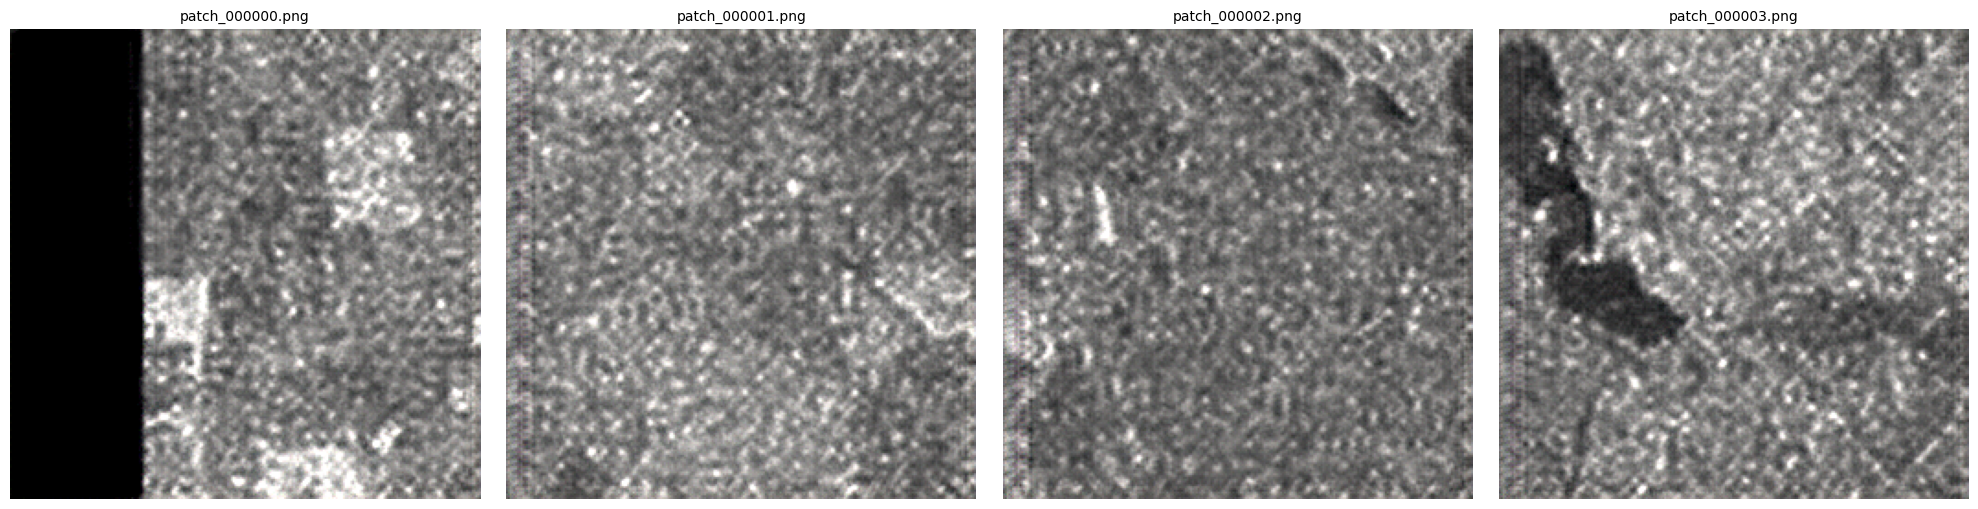

In [12]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# The exact folder we just found!
output_folder = "/kaggle/working/SRGAN-PyTorch/results/test_images/SRGAN_x4-ImageNet-Set5/"

# Grab the first 4 generated PNG files
files = sorted([f for f in os.listdir(output_folder) if f.endswith('.png')])[:4]

print("✅ Displaying your 18-Epoch Phase 2 SAR Output...")
plt.figure(figsize=(20, 5))

for i, file_name in enumerate(files):
    img_path = os.path.join(output_folder, file_name)
    img = mpimg.imread(img_path)
    
    plt.subplot(1, 4, i+1)
    plt.imshow(img, cmap='gray') # Grayscale is best for SAR
    plt.title(file_name, fontsize=10)
    plt.axis('off')
    
plt.tight_layout()
plt.show()

In [13]:
import os
import yaml

# Force notebook into the project folder
os.chdir('/kaggle/working/SRGAN-PyTorch')
config_file = './configs/train/SRGAN_x4-ImageNet.yaml'

# Open and edit the training configuration
with open(config_file, 'r') as f:
    cfg = yaml.safe_load(f)

# THE MAGIC NUMBER
cfg['TRAIN']['EPOCHS'] = 90

# Save it back
with open(config_file, 'w') as f:
    yaml.dump(cfg, f)

print("✅ Training configured for a full 90 epochs! Ready to launch.")

✅ Training configured for a full 90 epochs! Ready to launch.


In [14]:
import os
import yaml

os.chdir('/kaggle/working/SRGAN-PyTorch')
config_file = './configs/train/SRGAN_x4-ImageNet.yaml'

with open(config_file, 'r') as f:
    cfg = yaml.safe_load(f)

# Hardcoding the exact location of your 18-epoch progress
# Note: Using 'last' instead of 'best' ensures we are exactly at the end of epoch 18
cfg['TRAIN']['CHECKPOINT']['RESUME_G_MODEL'] = "/kaggle/working/SRGAN-PyTorch/results/SRGAN_x4-ImageNet/g_last.pth.tar"
cfg['TRAIN']['CHECKPOINT']['RESUME_D_MODEL'] = "/kaggle/working/SRGAN-PyTorch/results/SRGAN_x4-ImageNet/d_last.pth.tar"

# Set target to 90
cfg['TRAIN']['EPOCHS'] = 90

with open(config_file, 'w') as f:
    yaml.dump(cfg, f)

print("✅ Paths updated!")
print(f"G-Resume: {cfg['TRAIN']['CHECKPOINT']['RESUME_G_MODEL']}")
print(f"D-Resume: {cfg['TRAIN']['CHECKPOINT']['RESUME_D_MODEL']}")

✅ Paths updated!
G-Resume: /kaggle/working/SRGAN-PyTorch/results/SRGAN_x4-ImageNet/g_last.pth.tar
D-Resume: /kaggle/working/SRGAN-PyTorch/results/SRGAN_x4-ImageNet/d_last.pth.tar


In [15]:
!python train_gan.py --config_path ./configs/train/SRGAN_x4-ImageNet.yaml

2026-03-16 17:33:15.268164: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773682395.290017     144 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773682395.296806     144 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773682395.316639     144 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773682395.316698     144 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773682395.316710     144 computation_placer.cc:177] computation placer alr

In [16]:
# Force the number 90 into the YAML file
!sed -i 's/EPOCHS: [0-9]*/EPOCHS: 90/' /kaggle/working/SRGAN-PyTorch/configs/train/SRGAN_x4-ImageNet.yaml

# Verify it worked - it should print 'EPOCHS: 90'
!grep "EPOCHS:" /kaggle/working/SRGAN-PyTorch/configs/train/SRGAN_x4-ImageNet.yaml

  EPOCHS: 90
    EPOCHS: 90


In [17]:
import yaml
import os

os.chdir('/kaggle/working/SRGAN-PyTorch')
config_path = './configs/train/SRGAN_x4-ImageNet.yaml'

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

# Point to your Epoch 18 weights
cfg['TRAIN']['CHECKPOINT']['PRETRAINED_G_MODEL'] = "/kaggle/working/SRGAN-PyTorch/results/SRGAN_x4-ImageNet/g_last.pth.tar"

with open(config_path, 'w') as f:
    yaml.dump(cfg, f)

print("✅ Pretrained weight path locked!")

✅ Pretrained weight path locked!
